# ScienceQA Visual Challenge: Starter Notebook

This notebook provides a starting point for the ScienceQA Visual Multiple-Choice Challenge. It is based on the provided baseline solution, but has been adapted to be more of a general-purpose starter.

**Objective:** Build a model that can answer visual multiple-choice questions based on scientific diagrams and text.

**Baseline Model:** `HuggingFaceTB/SmolVLM-500M-Instruct` (~500 M params)
**Fine-Tuning:** QLoRA (4-bit NF4)
**Scoring:** Multiple-choice log-likelihood

---

In [1]:
# ── 0. Install libraries ──────────────────────────────────────────
# Run this cell to install the necessary Python packages.
# !pip install -q transformers==4.57.6 peft==0.18.1 bitsandbytes accelerate datasets pillow

In [1]:
# ── 1. Imports & Configuration ───────────────────────────────────────────────
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
# Adjust these paths to match your local environment
DATA_DIR   = Path("data")

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# ── Basic Settings ───────────────────────────────────────────────────────────
IMG_SIZE        = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3090


## 2. Load and Preprocess Data

In [2]:
# ── 2a. Load CSVs ─────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# The 'choices' column is a JSON string, so we parse it
for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head(2)

Train: 3,109 | Val: 1,048 | Test: 1,008


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


In [3]:
# ── 2b. Prompt Engineering ───────────────────────────────────────────────────
CHOICE_LETTERS = "ABCDEFGHIJ"

def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
    """
    Builds the text prompt for the Vision Language Model.
    The <image> token is required for the model to process the image.
    """
    context_parts = []
    lecture = row.get("lecture", "")
    hint    = row.get("hint", "")
    if pd.notna(lecture) and str(lecture).strip():
        context_parts.append(str(lecture).strip())
    if pd.notna(hint) and str(hint).strip():
        context_parts.append(str(hint).strip())
    context_str = "\n".join(context_parts)

    choices = row["choices"]
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices)
    )

    prompt = "<image>\n"
    if context_str:
        prompt += f"Context:\n{context_str}\n\n"
    prompt += f"Question: {row['question']}\n"
    prompt += f"Choices:\n{choices_str}\n"
    prompt += "Answer:"

    if include_answer:
        answer_idx = int(row['answer'])
        prompt += f" {CHOICE_LETTERS[answer_idx]}"

    return prompt

# Display an example prompt
print(build_prompt(train_df.iloc[0], include_answer=True))

<image>
Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that attract or compete for mates won't always successful

In [4]:
# ── 2c. PyTorch Dataset ───────────────────────────────────────────────────────
class ScienceQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, data_dir: Path, img_size: int = 224, is_train: bool = True):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.df)

    def _load_image(self, rel_path: str) -> Image.Image:
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BICUBIC)
        return img

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])

        if self.is_train:
            return {
                "image":  img,
                "text":   build_prompt(row, include_answer=True),
                "answer": int(row["answer"]),
            }
        else:
            return {
                "image":   img,
                "text":    build_prompt(row, include_answer=False),
                "choices": row["choices"],
                "answer":  int(row["answer"]) if "answer" in row else -1,
            }

train_ds = ScienceQADataset(train_df, DATA_DIR, img_size=IMG_SIZE, is_train=True)
val_ds   = ScienceQADataset(val_df,   DATA_DIR, img_size=IMG_SIZE, is_train=False)
test_ds  = ScienceQADataset(test_df,  DATA_DIR, img_size=IMG_SIZE, is_train=False)

print(f"Datasets created: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Datasets created: train=3109, val=1048, test=1008


## 3. Model Loading and Inference Example

This section loads `HuggingFaceTB/SmolVLM-500M-Instruct` and runs a quick inference example on one validation sample.

In [5]:
# ── 3a. Load SmolVLM model + run one inference example ───────────────────────
from transformers import AutoProcessor, AutoModelForVision2Seq

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
    low_cpu_mem_usage=True,
 )
if not torch.cuda.is_available():
    model.to(device)
model.eval()

# Pick a sample from validation set
sample = val_df.iloc[0]
sample_image = Image.open(DATA_DIR / sample["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
sample_prompt = build_prompt(sample, include_answer=False)

inputs = processor(
    text=[sample_prompt],
    images=[sample_image],
    return_tensors="pt",
)
inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
    )

decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Prompt:")
print(sample_prompt)
print("\nModel output:")
print(decoded)
print(f"\nGround-truth answer index: {sample['answer']}")

/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Prompt:
<image>
Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that attract or compete for mates won't always su

In [6]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

True
NVIDIA GeForce RTX 3090
VRAM: 25.8 GB


In [7]:
# ── 4. Log-likelihood scoring inference ──────────────────────────────────────
import torch
import torch.nn.functional as F
from tqdm import tqdm

def score_choices_log_likelihood(model, processor, image, prompt, choices):
    """
    For each answer choice, compute the log-likelihood of the model
    generating that choice token(s), conditioned on the prompt + image.
    Returns the index of the highest-scoring choice.
    """
    scores = []

    for choice in choices:
        full_text = prompt + f" {choice}"

        inputs = processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

        with torch.inference_mode():
            outputs = model(**inputs)
            logits = outputs.logits  # (1, seq_len, vocab_size)

        # Shift so we predict token t+1 from token t
        shift_logits = logits[:, :-1, :].contiguous()
        input_ids = inputs["input_ids"]
        shift_labels = input_ids[:, 1:].contiguous()

        # Token-level log probs
        log_probs = F.log_softmax(shift_logits, dim=-1)
        token_log_probs = log_probs.gather(2, shift_labels.unsqueeze(-1)).squeeze(-1)

        # Average log prob over all tokens (length-normalized)
        score = token_log_probs.mean().item()
        scores.append(score)

    return int(torch.tensor(scores).argmax().item())


# Quick sanity check on one val sample
sample = val_df.iloc[0]
sample_image = Image.open(DATA_DIR / sample["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
sample_prompt = build_prompt(sample, include_answer=False)

pred = score_choices_log_likelihood(model, processor, sample_image, sample_prompt, sample["choices"])
print(f"Predicted: {pred}, Ground truth: {sample['answer']}")

Predicted: 1, Ground truth: 0


In [7]:
# ── 5. Full validation evaluation + save predictions ─────────────────────────
results = []
correct = 0
total = 0

for idx in tqdm(range(len(val_df))):
    row = val_df.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    prompt = build_prompt(row, include_answer=False)

    pred = score_choices_log_likelihood(model, processor, image, prompt, row["choices"])
    
    results.append({"id": row["id"], "answer": pred, "ground_truth": int(row["answer"])})
    
    if pred == int(row["answer"]):
        correct += 1
    total += 1

baseline_acc = correct / total
print(f"\nBaseline val accuracy: {baseline_acc:.4f} ({correct}/{total})")

# Save val predictions
val_preds_df = pd.DataFrame(results)
val_preds_df.to_csv("val_predictions.csv", index=False)
print("Saved val_predictions.csv")

  2%|▏         | 17/1048 [00:50<50:38,  2.95s/it]


KeyboardInterrupt: 

In [ ]:
# ── 6. Generate test submission ───────────────────────────────────────────────
test_results = []

for idx in tqdm(range(len(test_df))):
    row = test_df.iloc[idx]
    image = Image.open(DATA_DIR / row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    prompt = build_prompt(row, include_answer=False)

    pred = score_choices_log_likelihood(model, processor, image, prompt, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
submission_df.to_csv("submission.csv", index=False)
print(submission_df.head())
print(f"\nSubmission shape: {submission_df.shape}")

100%|██████████| 1008/1008 [28:59<00:00,  1.73s/it]

           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       0
3  test_02425       0
4  test_00930       0

Submission shape: (1008, 2)


In [8]:
# ── 7. Count LoRA parameters ──────────────────────────────────────────────────
from peft import LoraConfig, get_peft_model

def count_lora_params(model, r, lora_alpha, target_modules):
    config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
    )
    peft_model = get_peft_model(model, config)
    trainable, total = peft_model.get_nb_trainable_parameters()
    print(f"r={r}, alpha={lora_alpha} | Trainable: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")
    peft_model.unload()  # clean up
    return trainable

# Try a few configs
for r in [8, 16, 32]:
    count_lora_params(
        model, r=r, lora_alpha=r*2,
        target_modules=["q_proj", "v_proj"]
    )

r=8, alpha=16 | Trainable: 1,114,112 / 508,596,416 (0.219%)
r=16, alpha=32 | Trainable: 2,228,224 / 509,710,528 (0.437%)


/home/rohan/pixels/venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


r=32, alpha=64 | Trainable: 4,456,448 / 511,938,752 (0.871%)


In [9]:
# ── 8. Load clean model + apply QLoRA ────────────────────────────────────────
from transformers import AutoProcessor, AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Reload base model clean in 4-bit
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.config.use_cache = False  # required for gradient checkpointing

# Apply LoRA
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 4,456,448 || all params: 511,938,752 || trainable%: 0.8705


Loading base model...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base model VRAM: 0.939 GB
Config 1: r=16, mods=2, params=2,228,224 | VRAM: 0.948 GB (+0.009 GB)


/home/rohan/pixels/venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Config 2: r=16, mods=2, params=2,228,224 | VRAM: 0.948 GB (+0.009 GB)
Config 3: r=16, mods=2, params=2,228,224 | VRAM: 0.948 GB (+0.009 GB)
Config 4: r=32, mods=2, params=4,456,448 | VRAM: 0.957 GB (+0.018 GB)
Config 5: r=32, mods=2, params=4,456,448 | VRAM: 0.957 GB (+0.018 GB)
Config 6: r=32, mods=2, params=4,456,448 | VRAM: 0.957 GB (+0.018 GB)
Config 7: r=32, mods=4, params=8,323,072 | VRAM: 0.972 GB (+0.033 GB)

Saved to logs/vram_study_20260423_174135.json


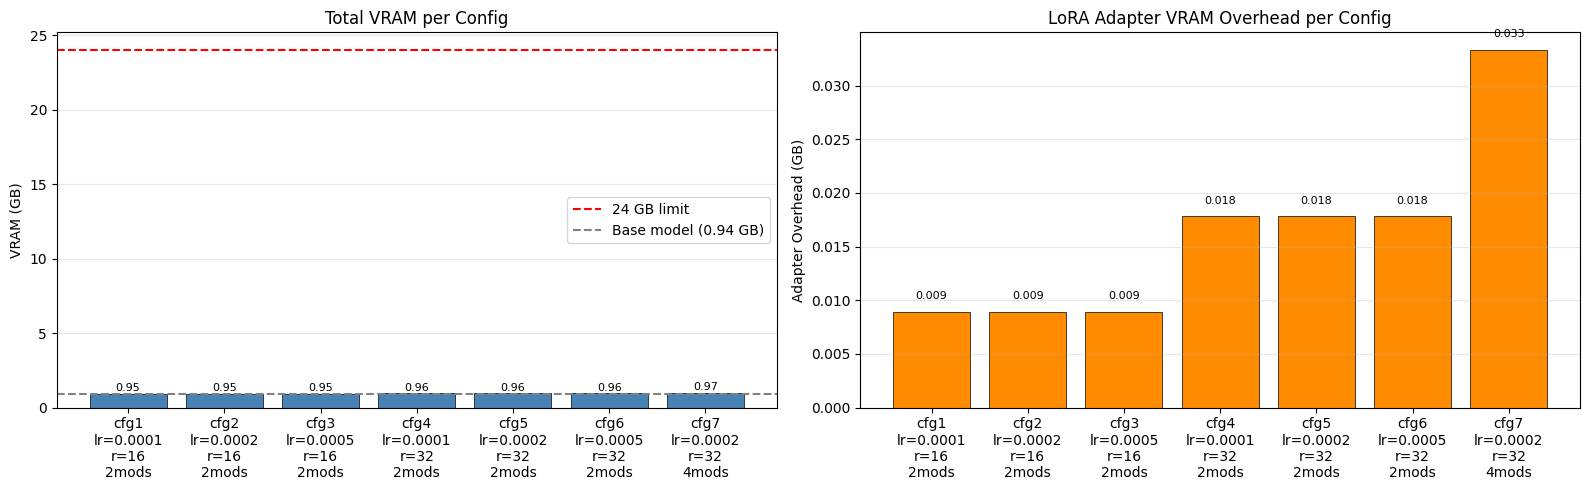

Saved VRAM study plot.

── Summary ──────────────────────────────────────────────────────────
ID    LR       r     Mods   Params       Total VRAM   Overhead
-----------------------------------------------------------------
1     0.0001   16    2      2,228,224    0.948        0.009 GB
2     0.0002   16    2      2,228,224    0.948        0.009 GB
3     0.0005   16    2      2,228,224    0.948        0.009 GB
4     0.0001   32    2      4,456,448    0.957        0.018 GB
5     0.0002   32    2      4,456,448    0.957        0.018 GB
6     0.0005   32    2      4,456,448    0.957        0.018 GB
7     0.0002   32    4      8,323,072    0.972        0.033 GB


In [10]:
# ── 9. VRAM study ─────────────────────────────────────────────────────────────
import gc
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
import json
import matplotlib.pyplot as plt
from datetime import datetime

LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)
study_id = datetime.now().strftime("%Y%m%d_%H%M%S")

configs = [
    {"lr": 1e-4, "r": 16, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 2e-4, "r": 16, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 5e-4, "r": 16, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 1e-4, "r": 32, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 2e-4, "r": 32, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 5e-4, "r": 32, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 2e-4, "r": 32, "target_modules": ["q_proj", "v_proj", "k_proj", "o_proj"]},
]

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

vram_results = []

# ── Load base model once ──────────────────────────────────────────────────────
print("Loading base model...")
base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base_model.config.use_cache = False
base_vram = torch.cuda.memory_allocated() / 1e9
print(f"Base model VRAM: {base_vram:.3f} GB")

# ── Measure each config ───────────────────────────────────────────────────────
for i, cfg in enumerate(configs):
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    lora_config = LoraConfig(
        r=cfg["r"],
        lora_alpha=cfg["r"] * 2,
        target_modules=cfg["target_modules"],
        lora_dropout=0.05,
        bias="none",
    )
    peft_model = get_peft_model(base_model, lora_config)
    trainable, total = peft_model.get_nb_trainable_parameters()

    vram_with_adapter = torch.cuda.memory_allocated() / 1e9
    adapter_overhead  = vram_with_adapter - base_vram

    print(f"Config {i+1}: r={cfg['r']}, mods={len(cfg['target_modules'])}, "
          f"params={trainable:,} | VRAM: {vram_with_adapter:.3f} GB (+{adapter_overhead:.3f} GB)")

    vram_results.append({
        "config_id":        i + 1,
        "lr":               cfg["lr"],
        "r":                cfg["r"],
        "target_modules":   cfg["target_modules"],
        "trainable_params": trainable,
        "total_params":     total,
        "base_vram_gb":     base_vram,
        "total_vram_gb":    vram_with_adapter,
        "adapter_overhead_gb": adapter_overhead,
    })

    base_model = peft_model.unload()
    del peft_model
    gc.collect()
    torch.cuda.empty_cache()

del base_model
gc.collect()
torch.cuda.empty_cache()

# ── Save ──────────────────────────────────────────────────────────────────────
with open(LOG_DIR / f"vram_study_{study_id}.json", "w") as f:
    json.dump(vram_results, f, indent=2)
print(f"\nSaved to logs/vram_study_{study_id}.json")

# ── Plot ──────────────────────────────────────────────────────────────────────
labels   = [f"cfg{r['config_id']}\nlr={r['lr']}\nr={r['r']}\n{len(r['target_modules'])}mods" for r in vram_results]
total_gb = [r["total_vram_gb"]      for r in vram_results]
overhead = [r["adapter_overhead_gb"] for r in vram_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(labels, total_gb, color="steelblue", edgecolor="black", linewidth=0.5)
axes[0].axhline(y=24.0, color="red", linestyle="--", label="24 GB limit")
axes[0].axhline(y=base_vram, color="gray", linestyle="--", label=f"Base model ({base_vram:.2f} GB)")
axes[0].set_ylabel("VRAM (GB)")
axes[0].set_title("Total VRAM per Config")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar, gb in zip(bars, total_gb):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{gb:.2f}", ha="center", va="bottom", fontsize=8)

bars2 = axes[1].bar(labels, overhead, color="darkorange", edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("Adapter Overhead (GB)")
axes[1].set_title("LoRA Adapter VRAM Overhead per Config")
axes[1].grid(axis="y", alpha=0.3)
for bar, gb in zip(bars2, overhead):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{gb:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(LOG_DIR / f"vram_study_{study_id}.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved VRAM study plot.")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────────────────────────────")
print(f"{'ID':<5} {'LR':<8} {'r':<5} {'Mods':<6} {'Params':<12} {'Total VRAM':<12} {'Overhead'}")
print("-" * 65)
for r in vram_results:
    print(f"{r['config_id']:<5} {r['lr']:<8} {r['r']:<5} {len(r['target_modules']):<6} "
          f"{r['trainable_params']:<12,} {r['total_vram_gb']:<12.3f} {r['adapter_overhead_gb']:.3f} GB")

In [ ]:
# ── 10. LR study (r=32, 3 configs) ───────────────────────────────────────────
import gc
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
import json
import matplotlib.pyplot as plt
from datetime import datetime

TRAIN_SUBSET_SIZE = 1000
GRAD_ACCUM        = 4

LOG_DIR  = Path("logs")
study_id = datetime.now().strftime("%Y%m%d_%H%M%S")

lr_configs = [1e-4, 2e-4, 5e-4]
train_subset = train_df.sample(TRAIN_SUBSET_SIZE, random_state=42).reset_index(drop=True)
study_results = []

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model...")
base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base_model.config.use_cache = False
print(f"Base model loaded. CUDA: {torch.cuda.memory_allocated()/1e9:.3f} GB")

for i, lr in enumerate(lr_configs):
    print(f"\n{'='*60}")
    print(f"Run {i+1}/3: lr={lr}, r=32, target_modules=['q_proj','v_proj']")
    print(f"{'='*60}")

    lora_config = LoraConfig(
        r=32,
        lora_alpha=64,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
    )
    peft_model = get_peft_model(base_model, lora_config)

    subset_ds     = ScienceQADataset(train_subset, DATA_DIR, img_size=IMG_SIZE, is_train=True)
    subset_loader = DataLoader(subset_ds, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)

    optimizer    = AdamW(peft_model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = max(1, len(subset_loader) // GRAD_ACCUM)
    warmup_steps = max(1, int(total_steps * 0.03))
    scheduler    = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    peft_model.train()
    total_loss  = 0
    step_losses = []
    optimizer.zero_grad()

    for step, (inputs, answers) in enumerate(tqdm(subset_loader, desc=f"lr={lr}")):
        inputs  = {k: v.to(peft_model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}
        outputs = peft_model(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()
        step_losses.append(outputs.loss.item())

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(peft_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del outputs, loss
        torch.cuda.empty_cache()

    avg_loss   = total_loss / len(subset_loader)
    final_loss = step_losses[-1]
    print(f"Avg loss: {avg_loss:.4f} | Final loss: {final_loss:.4f}")

    study_results.append({
        "lr":              lr,
        "r":               32,
        "avg_train_loss":  avg_loss,
        "final_step_loss": final_loss,
        "step_losses":     step_losses,
    })

    base_model = peft_model.unload()
    del peft_model, optimizer, scheduler, subset_loader, subset_ds
    gc.collect()
    torch.cuda.empty_cache()

del base_model
gc.collect()
torch.cuda.empty_cache()

# ── Save ──────────────────────────────────────────────────────────────────────
with open(LOG_DIR / f"lr_study_{study_id}.json", "w") as f:
    json.dump(study_results, f, indent=2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "darkorange", "seagreen"]

for r, color in zip(study_results, colors):
    axes[0].plot(r["step_losses"], label=f"lr={r['lr']}", color=color, alpha=0.8)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves by LR")
axes[0].legend()
axes[0].grid(alpha=0.3)

labels     = [str(r["lr"]) for r in study_results]
avg_losses = [r["avg_train_loss"] for r in study_results]
bars = axes[1].bar(labels, avg_losses, color=colors, edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Avg Train Loss")
axes[1].set_title("Avg Train Loss by LR")
axes[1].grid(axis="y", alpha=0.3)
for bar, loss in zip(bars, avg_losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{loss:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(LOG_DIR / f"lr_study_{study_id}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── Summary (sorted by avg loss) ─────────────────────────")
print(f"{'LR':<10} {'Avg Loss':<12} {'Final Loss'}")
print("-" * 35)
for r in sorted(study_results, key=lambda x: x["avg_train_loss"]):
    print(f"{r['lr']:<10} {r['avg_train_loss']:<12.4f} {r['final_step_loss']:.4f}")

best_lr = min(study_results, key=lambda x: x["avg_train_loss"])["lr"]
print(f"\nBest LR: {best_lr}")

Loading base model...
Base model loaded. CUDA: 1.364 GB

Run 1/3: lr=0.0001, r=32, target_modules=['q_proj','v_proj']


lr=0.0001:   1%|          | 2/250 [02:06<3:54:31, 56.74s/it] 

In [10]:
# ── 9. Training loop ──────────────────────────────────────────────────────────
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
import json
import matplotlib.pyplot as plt
from datetime import datetime

# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS       = 3
BATCH_SIZE   = 4
GRAD_ACCUM   = 4   # effective batch size = 16
LR           = 2e-4
WARMUP_RATIO = 0.03

# ── Logging setup ─────────────────────────────────────────────────────────────
LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log = {
    "run_id": run_id,
    "hyperparameters": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
        "lr": LR,
        "warmup_ratio": WARMUP_RATIO,
        "lora_r": 32,
        "lora_alpha": 64,
        "target_modules": ["q_proj", "v_proj"],
        "trainable_params": 4_456_448,
        "total_params": 511_938_752,
        "model": MODEL_ID,
    },
    "train_loss_per_step": [],
    "train_loss_per_epoch": [],
    "val_accuracy_per_epoch": [],
    "baseline_val_accuracy": 0.3187,
    "baseline_leaderboard_score": 0.368,
}

# ── Collate function ──────────────────────────────────────────────────────────
def collate_fn(batch):
    images  = [b["image"] for b in batch]
    texts   = [b["text"]  for b in batch]
    answers = [b["answer"] for b in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )
    inputs["labels"] = inputs["input_ids"].clone()
    return inputs, torch.tensor(answers)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
)

# ── Optimizer + scheduler ─────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# ── Plot helpers ──────────────────────────────────────────────────────────────
def plot_training_loss(log):
    steps = [s["step"] for s in log["train_loss_per_step"]]
    losses = [s["loss"] for s in log["train_loss_per_step"]]
    epoch_losses = log["train_loss_per_epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(steps, losses, alpha=0.4, color="steelblue", linewidth=0.8)
    window = 30
    if len(losses) >= window:
        smoothed = pd.Series(losses).rolling(window).mean()
        axes[0].plot(steps, smoothed, color="steelblue", linewidth=2, label=f"Smoothed (w={window})")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss per Step")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(range(1, len(epoch_losses)+1), epoch_losses, marker="o", color="steelblue", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Avg Loss")
    axes[1].set_title("Training Loss per Epoch")
    axes[1].set_xticks(range(1, EPOCHS+1))
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(LOG_DIR / f"training_loss_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved training loss plot.")

def plot_val_accuracy(log):
    epochs = range(1, len(log["val_accuracy_per_epoch"])+1)
    accs = log["val_accuracy_per_epoch"]

    plt.figure(figsize=(7, 4))
    plt.axhline(y=log["baseline_val_accuracy"], color="gray", linestyle="--", label=f"Baseline ({log['baseline_val_accuracy']:.4f})")
    plt.plot(epochs, accs, marker="o", color="darkorange", linewidth=2, label="Fine-tuned")
    plt.xlabel("Epoch")
    plt.ylabel("Val Accuracy")
    plt.title("Validation Accuracy per Epoch")
    plt.xticks(range(1, EPOCHS+1))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(LOG_DIR / f"val_accuracy_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved val accuracy plot.")

# ── Training ──────────────────────────────────────────────────────────────────
global_step = 0
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    optimizer.zero_grad()

    for step, (inputs, answers) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

        outputs = model(**inputs)
        loss = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        log["train_loss_per_step"].append({
            "step": global_step,
            "epoch": epoch + 1,
            "loss": outputs.loss.item(),
        })

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["train_loss_per_epoch"].append(avg_loss)
    print(f"Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

    # ── Per-epoch val accuracy ────────────────────────────────────────────────
    print(f"Running val eval after epoch {epoch+1}...")
    model.eval()
    correct = 0
    for idx in tqdm(range(len(val_df)), desc="Val eval"):
        row = val_df.iloc[idx]
        image = Image.open(DATA_DIR / row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        prompt = build_prompt(row, include_answer=False)
        pred = score_choices_log_likelihood(model, processor, image, prompt, row["choices"])
        if pred == int(row["answer"]):
            correct += 1
    val_acc = correct / len(val_df)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Epoch {epoch+1} | val accuracy: {val_acc:.4f}")
    model.train()

    # ── Save checkpoint + full trainer state ──────────────────────────────────
    ckpt_path = LOG_DIR / f"ckpt_epoch{epoch+1}_{run_id}"
    model.save_pretrained(ckpt_path)

    torch.save({
        "epoch": epoch + 1,
        "global_step": global_step,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "log": log,
    }, LOG_DIR / f"trainer_state_epoch{epoch+1}_{run_id}.pt")

    with open(LOG_DIR / f"log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)

    print(f"Saved checkpoint + trainer state to {ckpt_path}")

# ── Final plots ───────────────────────────────────────────────────────────────
plot_training_loss(log)
plot_val_accuracy(log)

with open(LOG_DIR / f"log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)
print(f"\nAll logs saved to logs/log_{run_id}.json")
print("Training complete.")

Epoch 1:   0%|          | 0/778 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/778 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [12]:
def collate_fn(batch):
    images  = [b["image"] for b in batch]
    texts   = [b["text"]  for b in batch]
    answers = [b["answer"] for b in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )
    inputs["labels"] = inputs["input_ids"].clone()
    return inputs, torch.tensor(answers)

In [ ]:
# ── 9. Hyperparameter Search ──────────────────────────────────────────────────
import gc
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
import json
import matplotlib.pyplot as plt
from datetime import datetime

# ── Study config ──────────────────────────────────────────────────────────────
TRAIN_SUBSET_SIZE = 1000
VAL_SUBSET_SIZE   = 300
STUDY_EPOCHS      = 1
GRAD_ACCUM        = 4

LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

study_id = datetime.now().strftime("%Y%m%d_%H%M%S")

configs = [
    {"lr": 1e-4, "r": 16, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 2e-4, "r": 16, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 5e-4, "r": 16, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 1e-4, "r": 32, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 2e-4, "r": 32, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 5e-4, "r": 32, "target_modules": ["q_proj", "v_proj"]},
    {"lr": 2e-4, "r": 32, "target_modules": ["q_proj", "v_proj", "k_proj", "o_proj"]},
]

# Fixed subsets so every config sees the same data
train_subset = train_df.sample(TRAIN_SUBSET_SIZE, random_state=42).reset_index(drop=True)
val_subset   = val_df.sample(VAL_SUBSET_SIZE,   random_state=42).reset_index(drop=True)

study_results = []

# ── Load base model ONCE ──────────────────────────────────────────────────────
print("Loading base model once...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base_model.config.use_cache = False
print(f"Base model loaded. CUDA memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# ── Run each config ───────────────────────────────────────────────────────────
for i, cfg in enumerate(configs):
    print(f"\n{'='*60}")
    print(f"Config {i+1}/{len(configs)}: lr={cfg['lr']}, r={cfg['r']}, modules={cfg['target_modules']}")
    print(f"{'='*60}")

    # Apply fresh LoRA adapter on top of base model
    lora_config = LoraConfig(
        r=cfg["r"],
        lora_alpha=cfg["r"] * 2,
        target_modules=cfg["target_modules"],
        lora_dropout=0.05,
        bias="none",
    )
    peft_model = get_peft_model(base_model, lora_config)
    trainable, _ = peft_model.get_nb_trainable_parameters()
    print(f"Trainable params: {trainable:,}")

    # Dataset + loader for subset
    subset_ds = ScienceQADataset(train_subset, DATA_DIR, img_size=IMG_SIZE, is_train=True)
    subset_loader = DataLoader(
        subset_ds,
        batch_size=4,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
    )

    optimizer = AdamW(peft_model.parameters(), lr=cfg["lr"], weight_decay=0.01)
    total_steps  = max(1, len(subset_loader) // GRAD_ACCUM)
    warmup_steps = max(1, int(total_steps * 0.03))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    # ── Train 1 epoch ─────────────────────────────────────────────────────────
    peft_model.train()
    total_loss = 0
    step_losses = []
    optimizer.zero_grad()

    for step, (inputs, answers) in enumerate(tqdm(subset_loader, desc="Training")):
        inputs = {k: v.to(peft_model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}
        outputs = peft_model(**inputs)
        loss = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()
        step_losses.append(outputs.loss.item())

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(peft_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    avg_loss = total_loss / len(subset_loader)
    print(f"Avg train loss: {avg_loss:.4f}")

    # ── Val eval ──────────────────────────────────────────────────────────────
    peft_model.eval()
    correct = 0
    for idx in tqdm(range(len(val_subset)), desc="Val eval"):
        row = val_subset.iloc[idx]
        image = Image.open(DATA_DIR / row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        prompt = build_prompt(row, include_answer=False)
        pred = score_choices_log_likelihood(peft_model, processor, image, prompt, row["choices"])
        if pred == int(row["answer"]):
            correct += 1
    val_acc = correct / len(val_subset)
    print(f"Val accuracy: {val_acc:.4f}")

    study_results.append({
        "config_id": i + 1,
        "lr": cfg["lr"],
        "r": cfg["r"],
        "target_modules": cfg["target_modules"],
        "trainable_params": trainable,
        "avg_train_loss": avg_loss,
        "val_accuracy": val_acc,
        "step_losses": step_losses,
    })

    # ── Discard LoRA adapter, keep base model ─────────────────────────────────
    base_model = peft_model.unload()
    del peft_model, optimizer, scheduler, subset_loader, subset_ds
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Adapter unloaded. CUDA memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# ── Clean up base model ───────────────────────────────────────────────────────
del base_model
gc.collect()
torch.cuda.empty_cache()

# ── Save results ──────────────────────────────────────────────────────────────
with open(LOG_DIR / f"hparam_study_{study_id}.json", "w") as f:
    json.dump(study_results, f, indent=2)
print(f"\nSaved study results to logs/hparam_study_{study_id}.json")

# ── Plot results ──────────────────────────────────────────────────────────────
labels = [f"cfg{r['config_id']}\nlr={r['lr']}\nr={r['r']}\n{len(r['target_modules'])} mods" for r in study_results]
val_accs = [r["val_accuracy"] for r in study_results]
train_losses = [r["avg_train_loss"] for r in study_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(labels, val_accs, color="darkorange", edgecolor="black", linewidth=0.5)
axes[0].axhline(y=0.3187, color="gray", linestyle="--", label="Baseline (0.3187)")
axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Val Accuracy by Config")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, val_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{acc:.3f}", ha="center", va="bottom", fontsize=8)

bars2 = axes[1].bar(labels, train_losses, color="steelblue", edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("Avg Train Loss")
axes[1].set_title("Train Loss by Config")
axes[1].grid(axis="y", alpha=0.3)
for bar, loss in zip(bars2, train_losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{loss:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(LOG_DIR / f"hparam_study_{study_id}.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hyperparameter study plot.")

# ── Print summary table ───────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────────────────────")
print(f"{'ID':<5} {'LR':<8} {'r':<5} {'Modules':<6} {'Params':<12} {'Loss':<8} {'Val Acc'}")
print("-" * 60)
for r in sorted(study_results, key=lambda x: x["val_accuracy"], reverse=True):
    print(f"{r['config_id']:<5} {r['lr']:<8} {r['r']:<5} {len(r['target_modules']):<6} {r['trainable_params']:<12,} {r['avg_train_loss']:<8.4f} {r['val_accuracy']:.4f}")

Loading base model once...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base model loaded. CUDA memory: 2.51 GB

Config 1/7: lr=0.0001, r=16, modules=['q_proj', 'v_proj']
Trainable params: 2,228,224


Training:   0%|          | 1/250 [02:15<9:21:04, 135.20s/it]